In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, "..", "de"))

  Activating project at `~/Documents/boes/PELLM/code/de`


[0.0, 6.296289920806885, 13.264014959335327, 20.849968910217285, 29.384782791137695, 38.91328287124634, 48.35013294219971, 58.94516897201538, 69.83066582679749, 81.09337878227234, 93.25938582420349, 106.2523238658905, 120.66110682487488, 135.55544900894165, 151.27393794059753, 167.8578338623047, 185.94890594482422, 202.90367889404297, 221.07447290420532, 240.3179898262024, 259.73466181755066, 280.1913528442383, 300.8655250072479, 322.9410128593445, 345.2601490020752, 368.7082939147949, 392.9693307876587, 424.1635468006134, 451.84671092033386, 478.75606179237366, 507.9193480014801, 536.7269477844238, 566.5216979980469, 597.588418006897, 640.6092917919159, 672.7403018474579, 707.7132728099823, 743.1570959091187, 780.7102677822113, 819.7703249454498, 858.4226088523865, 899.0926008224487, 942.3826429843903, 988.1978569030762, 1029.5329608917236, 1072.2361249923706, 1115.9906208515167, 1163.9314889907837, 1211.5529389381409, 1259.4245159626007, 1307.1182289123535, 1354.7523729801178, 1403.2

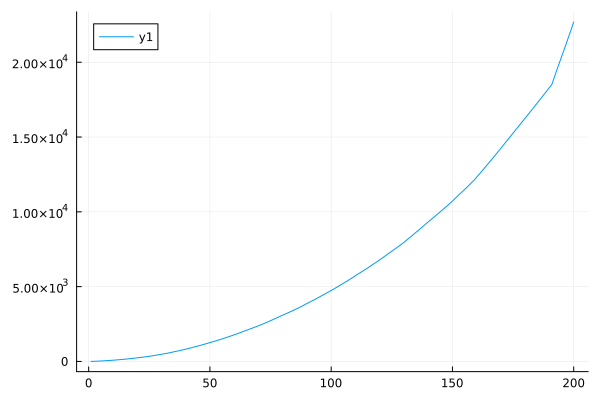

In [2]:
using Plots
using DataFrames
using Statistics

dir = "timing"
kernel = "Additive"
dataset = "GB1"

function parse_run(dir, kernel, dataset, vatiant, dim)
    lines = []
    open(dir*"/"*kernel*"/"*dataset*"/"*vatiant*"/"*dim*".out") do file
            for line in eachline(file)
                push!(lines, line)
            end
        end
    # log time for each oter from the lines
    times = []
    for line in lines
        if occursin(": time:", line)
            time = replace(line, "[ Info: time: " => "")
            time = parse(Float64, time)
            push!(times, time)
        end
    end
    return times.-times[1]
end

t = parse_run(dir, kernel, dataset, "variant_1", "dimension_1028")
println(t)
plot(t)

In [3]:

dir = "timing"
kernels = ["Additive", "Conic", "Matern", "Matern32"]
datasets = ["GB1", "PhoQ", "TrpB"]
variants = collect(1:100)
dimensions = [1,5,10,20,50,75,100,1028]

result = DataFrame()  # Initialize result as a DataFrame

i = 1
for kernel in kernels
    j = 1
    for dataset in datasets
        k = 1
        for variant in variants
            l = 1
            runs = []
            for dimension in dimensions
                try
                    t = parse_run(dir, kernel, dataset, "variant_$variant", "dimension_$dimension")
                    push!(result, (kernel=kernel, dataset=dataset, variant=variant, dimension=dimension, times=t))  # Store results in DataFrame
                catch
                end
                i+=1
            end
            k+=1
        end
        j+=1
    end
    i+=1
end
result

Row,kernel,dataset,variant,dimension,times
,String,String,Int64,Int64,Array…
1,Additive,GB1,1,1,"[0.0, 2.62275, 5.39957, 8.4083, 11.6782, 15.1159, 18.8036, 22.7367, 26.8715, 31.2661 … 7216.92, 7538.93, 7849.08, 8164.13, 8492.49, 8826.84, 9137.43, 9452.78, 9782.18, 10095.5]"
2,Additive,GB1,1,5,"[0.0, 2.72041, 5.51921, 8.57882, 12.0111, 15.4975, 19.2167, 23.1714, 27.4177, 31.8433 … 8022.7, 8476.93, 8946.2, 9411.1, 9879.3, 10325.0, 10793.1, 11261.4, 11724.9, 12191.5]"
3,Additive,GB1,1,10,"[0.0, 2.75457, 5.60171, 8.66547, 11.9767, 15.4931, 19.2682, 23.2865, 27.8594, 32.9701 … 7456.45, 7798.54, 8151.16, 8499.35, 8852.93, 9214.75, 9572.8, 9913.1, 10270.5, 10631.6]"
4,Additive,GB1,1,20,"[0.0, 2.98004, 6.06995, 9.45547, 13.0323, 17.7049, 22.1494, 26.7497, 31.8977, 37.3373 … 8097.86, 8486.41, 8869.79, 9253.01, 9645.93, 9997.5, 10367.7, 10734.4, 11088.6, 11457.7]"
5,Additive,GB1,1,50,"[0.0, 3.19609, 6.69257, 10.276, 13.8479, 17.9592, 22.2836, 26.8565, 31.7032, 36.7513 … 7955.42, 8345.29, 8723.91, 9133.92, 9513.55, 9881.62, 10260.7, 10657.7, 11027.3, 11401.9]"
6,Additive,GB1,1,75,"[0.0, 2.93501, 5.96802, 9.47502, 13.1983, 17.1805, 21.4754, 25.979, 30.7202, 35.6847 … 8121.57, 8464.3, 8821.86, 9171.24, 9538.77, 9860.46, 10216.3, 10549.3, 10878.6, 11199.2]"
7,Additive,GB1,1,100,"[0.0, 3.01462, 6.4991, 10.1893, 14.1297, 18.3309, 22.7998, 27.559, 32.5566, 37.7832 … 8203.76, 8547.6, 8890.11, 9254.39, 9595.46, 9945.43, 10288.9, 10621.0, 10965.0, 11293.2]"
8,Additive,GB1,1,1028,"[0.0, 6.29629, 13.264, 20.85, 29.3848, 38.9133, 48.3501, 58.9452, 69.8307, 81.0934 … 18522.0, 18990.2, 19464.5, 19921.4, 20381.7, 20831.0, 21274.9, 21753.9, 22210.3, 22691.0]"
9,Additive,GB1,2,1,"[0.0, 2.69895, 5.51813, 8.60444, 11.8889, 15.3711, 19.1072, 23.0505, 27.2539, 31.6788 … 7940.48, 8312.9, 8697.47, 9097.09, 9491.42, 9858.01, 10233.3, 10624.9, 11007.2, 11379.5]"


In [ ]:
# using CSV

# CSV.write("time_data.csv", result)

"time_data.csv"